## Exercise 1: Duan Nguyen
$$
w_p =
\begin{matrix}
10\\ 
20\\
30
\end{matrix},
\quad
K =
\begin{matrix}
2 & 0 & 10\\[4pt]
0 & 2 & 20\\[4pt]
0 & 0 & 1
\end{matrix}
$$
The world to camera homogeneous transform:
$$
{}^{c}T_{W} =
\begin{matrix}
0 & 1 & 0 & -1 \\[4pt]
-1 & 0 & 0 & 2 \\[4pt]
0 & 0 & 1 & 0 \\
0 & 0 & 0 & 1
\end{matrix}
=
\begin{matrix}
r11 & r12 & r13 & t1 \\[4pt]
r21 & r22 & r23 & t2 \\[4pt]
r31 & r32 & r33 & t3 \\
0 & 0 & 0 & 1
\end{matrix}
$$
$$
[R|t] =
\begin{matrix}
0 & 1 & 0 & -1\\[4pt]
-1 & 0 & 0 & 2\\[4pt]
0 & 0 & 1 & 0
\end{matrix}
$$
## 1)
$$
P = K [R \;|\; t]
$$
$$
P =
\begin{matrix}
2 & 0 & 10 \\[4pt]
0 & 2 & 20 \\[4pt]
0 & 0 & 1
\end{matrix}
*
\begin{matrix}
0 & 1 & 0 & -1 \\[4pt]
-1 & 0 & 0 & 2 \\[4pt]
0 & 0 & 1 & 0
\end{matrix}
=
\begin{matrix}
0 & 2 & 10 & -2 \\[4pt]
-2 & 0 & 20 & 4 \\[4pt]
0 & 0 & 1 & 0
\end{matrix}
$$
$$
P =
\begin{matrix}
0 & 2 & 10 & -2 \\[4pt]
-2 & 0 & 20 & 4 \\[4pt]
0 & 0 & 1 & 0
\end{matrix}
$$
## 2)
Homogeneous world coordinates:
$$
w_p^h =
\begin{matrix}
10 \\[4pt]
20 \\[4pt]
30 \\[4pt]
1
\end{matrix}
$$
Then:
$$
x = P \, w_p^h =
\begin{matrix}
338 \\[4pt]
584 \\[4pt]
30
\end{matrix}
$$
$$
x^T = X Y Z --> x^h = X/Z Y/Z
$$
$$
X/Z = \frac{338}{30} = 11.2667, \quad
Y/Z = \frac{584}{30} = 19.4667
$$
$$(x^h = (11.27, 19.47))$$
## 3)
$$
x^h = (\text{round}(11.27), \text{round}(19.47)) = (11, 19)
$$

In [5]:
import numpy as np
import cv2 as cv
import glob
import yaml

import matplotlib.pyplot as plt

In [14]:
# termination criteria; CHANGE the second number to size of each square
criteria = (cv.TERM_CRITERIA_EPS + cv.TERM_CRITERIA_MAX_ITER, 30, 0.001)

# define checkerboard dimensions
CHECKERBOARD = (7, 5)  # number of inner corners per row and column;  ADJUST based on checkerboard's number of INNER squares
square_size = 30.0  # mm per square; CHANGE to your square side length

# prepare object points, like (0,0,0), (1,0,0), (2,0,0) ....,(6,5,0)
objp = np.zeros((CHECKERBOARD[0]*CHECKERBOARD[1],3), np.float32) # adjust based on checkerboard's number of INNER squares
objp[:,:2] = np.mgrid[0:CHECKERBOARD[0], 0:CHECKERBOARD[1]].T.reshape(-1,2) * square_size

# Arrays to store object points and image points from all the images.
objpoints = [] # 3d point in real world space
imgpoints = [] # 2d points in image plane.

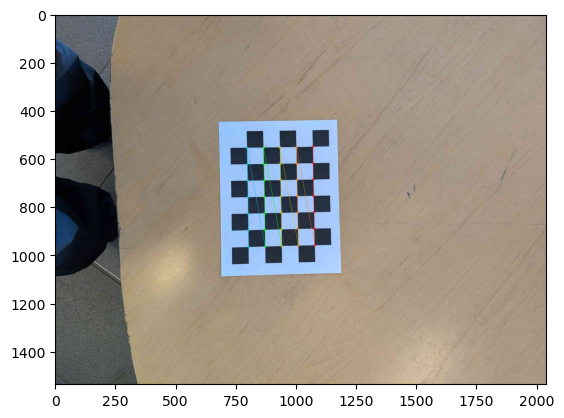

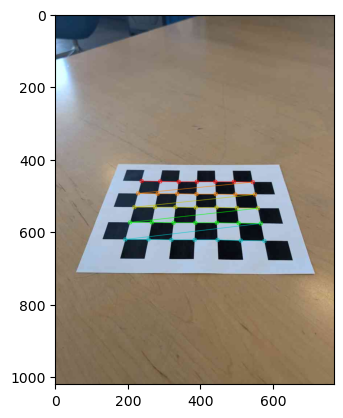

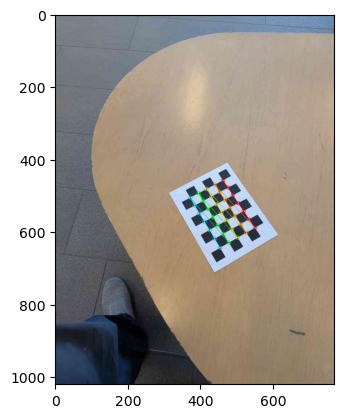

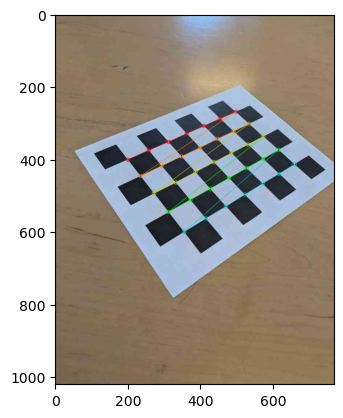

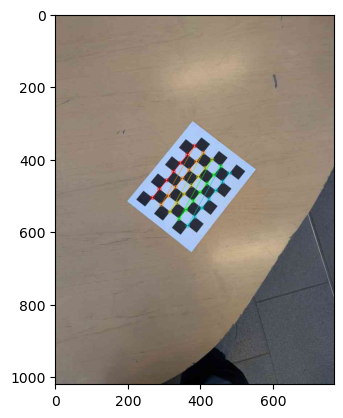

Number of images used for calibration:  5


In [15]:
images = glob.glob(r'hw08_image/hw08*.jpg')

counter = 0
for fname in images:  
    img = cv.imread(fname) # Capture frame-by-frame
    gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
    
    # Find the chess board corners
    ret, corners = cv.findChessboardCorners(gray, (CHECKERBOARD[0],CHECKERBOARD[1]), None)

    # If found, add object points, image points (after refining them)
    if ret == True:
        objpoints.append(objp)  

        corners2 = cv.cornerSubPix(gray,corners,(11,11),(-1,-1),criteria)
        imgpoints.append(corners2)

        # Draw and display the corners
        counter += 1
        img = cv.drawChessboardCorners(img, (CHECKERBOARD[0],CHECKERBOARD[1]), corners2, ret)
        
        # cv.imshow('img', img)
        # cv.waitKey(1000)
        plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
        plt.show()


print("Number of images used for calibration: ", counter)

cv.destroyAllWindows()

In [11]:
# calibration
ret, mtx, dist, rvecs, tvecs = cv.calibrateCamera(objpoints, imgpoints, gray.shape[::-1], None, None)

print(mtx)
print(dist)

# transform the matrix and distortion coefficients to writable lists
data = {'camera_matrix': np.asarray(mtx).tolist(),
        'dist_coeff': np.asarray(dist).tolist()}

# save it to a yaml file
with open("calibration_matrix.yaml", "w") as f:
    yaml.dump(data, f)

[[802.02413553   0.         393.1778152 ]
 [  0.         794.17256051 455.41406474]
 [  0.           0.           1.        ]]
[[ 0.09961558 -0.11973051 -0.00978398 -0.00184373  0.0516757 ]]


## What camera did you use (e.g., your phone’s camera?) 
Google Pixel 9
## What was the size of the calibration board and the size of each square? 
8 by 6 and the size of each square is 30 mm.
## How many pictures of the calibration board you took? 
5 pictures.
## Show calibration outputs, including images, intrinsic matrix, and distortion parameter
$$
K=
\begin{matrix}
8.0e+2 & 0.0e+0 & 3.9e+2\\[4pt]
0.0e+0 & 0.0e+0 & 0.0e+0\\[4pt]
0.0e+0 & 0.0e+0 & 1.0e+0
\end{matrix}
$$
$$
distortion_parameter = [ 0.09961558 -0.11973051 -0.00978398 -0.00184373  0.0516757 ]
$$